In [1]:
import os
import sys
sys.path.append("/home/zangzeyuan/HallE")
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
# pip install opencv-python
from PIL import Image

import torch
import torch.nn.functional as F

from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.utils import disable_torch_init
from llava.mm_utils import process_images, tokenizer_image_token, get_model_name_from_path

[2025-12-26 01:19:10,784] [INFO] [real_accelerator.py:110:get_accelerator] Setting ds_accelerator to cuda (auto detect)


In [2]:
def aggregate_llm_attention(attn):
    '''Extract average attention vector'''
    avged = []
    for layer in attn:
        layer_attns = layer.squeeze(0)
        attns_per_head = layer_attns.mean(dim=0)
        vec = torch.concat((
            # We zero the first entry because it's what's called
            # null attention (https://aclanthology.org/W19-4808.pdf)
            torch.tensor([0.]),
            # usually there's only one item in attns_per_head but
            # on the first generation, there's a row for each token
            # in the prompt as well, so take [-1]
            attns_per_head[-1][1:].cpu(),
            # attns_per_head[-1].cpu(),
            # add zero for the final generated token, which never
            # gets any attention
            torch.tensor([0.]),
        ))
        avged.append(vec / vec.sum())
    return torch.stack(avged).mean(dim=0)


def load_image(image_path_or_url):
    if image_path_or_url.startswith('http://') or image_path_or_url.startswith('https://'):
        response = requests.get(image_path_or_url)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(image_path_or_url).convert('RGB')
    return image

def show_mask_on_image(img, mask):
    img = np.float32(img) / 255
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_HSV)
    hm = np.float32(heatmap) / 255
    cam = hm + np.float32(img)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam), heatmap


def aggregate_vit_attention(attn, select_layer=-2, all_prev_layers=True):
    '''Assuming LLaVA-style `select_layer` which is -2 by default'''
    if all_prev_layers:
        avged = []
        for i, layer in enumerate(attn):
            if i > len(attn) + select_layer:
                break
            layer_attns = layer.squeeze(0)
            attns_per_head = layer_attns.mean(dim=0)
            vec = attns_per_head[1:, 1:].cpu() # the first token is <CLS>
            avged.append(vec / vec.sum(-1, keepdim=True))
        return torch.stack(avged).mean(dim=0)
    else:
        layer = attn[select_layer]
        layer_attns = layer.squeeze(0)
        attns_per_head = layer_attns.mean(dim=0)
        vec = attns_per_head[1:, 1:].cpu()
        return vec / vec.sum(-1, keepdim=True)

def heterogenous_stack(vecs):
    '''Pad vectors with zeros then stack'''
    max_length = max(v.shape[0] for v in vecs)
    return torch.stack([
        torch.concat((v, torch.zeros(max_length - v.shape[0])))
        for v in vecs
    ])

In [3]:
model_path = "/work/zangzeyuan/exp10_llava_verifier_logits_scalar_frozen_1.0_joint_6+3+1k_1ep_16bz_3e5"

# load the model
load_bf16 = False
load_8bit = False
load_4bit = False

disable_torch_init()

model_name = get_model_name_from_path(model_path)
model_version = 'llava_verifier'
model_vision = 'openai/clip-vit-large-patch14-336'
tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path, 
    None, # model_base
    model_name, 
    model_version,
    model_vision,
    load_bf16,
    load_8bit, 
    load_4bit
)

LlavaConfig {
  "_name_or_path": "/work/zangzeyuan/exp10_llava_verifier_logits_scalar_frozen_1.0_joint_6+3+1k_1ep_16bz_3e5",
  "alpha_type": "scalar",
  "architectures": [
    "LlavaLlamaVerifierForCausalLM"
  ],
  "attention_bias": false,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "freeze_alpha": true,
  "freeze_mm_mlp_adapter": false,
  "freeze_mm_vision_resampler": false,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "image_aspect_ratio": "pad",
  "image_grid_pinpoints": null,
  "initializer_range": 0.02,
  "intermediate_size": 11008,
  "logits_attend": true,
  "max_length": 4096,
  "max_position_embeddings": 4096,
  "mm_hidden_size": 1024,
  "mm_projector_lr": null,
  "mm_projector_type": "mlp2x_gelu",
  "mm_resampler_type": null,
  "mm_use_im_patch_token": false,
  "mm_use_im_start_end": false,
  "mm_vision_select_feature": "patch",
  "mm_vision_select_layer": -2,
  "mm_vision_tower": "openai/clip-vit-large-patch14-336",
  "model_type": "llava",
  "num_attention_heads": 32,
  

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of the model checkpoint at /work/zangzeyuan/exp10_llava_verifier_logits_scalar_frozen_1.0_joint_6+3+1k_1ep_16bz_3e5 were not used when initializing LlavaLlamaVerifierForCausalLM: ['model.vision_tower.vision_tower.vision_model.encoder.layers.9.self_attn.k_proj.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.4.self_attn.out_proj.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.11.self_attn.k_proj.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.7.self_attn.v_proj.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.8.self_attn.k_proj.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.2.self_attn.v_proj.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.self_attn.v_proj.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.9.mlp.fc1.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.bias', 'model.vision_tower.vision_towe

exp10_llava_verifier_logits_scalar_frozen_1.0_joint_6+3+1k_1ep_16bz_3e5
v1


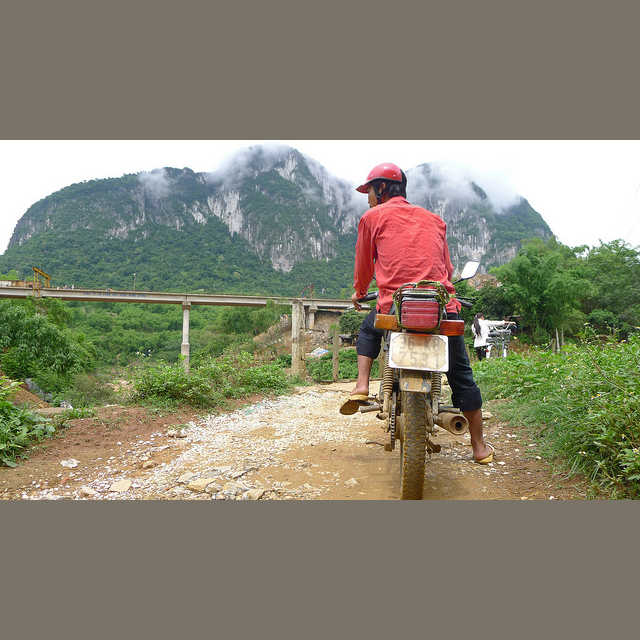

Describe this image as detailed as possible.


In [4]:
image_path_or_url = "/home/zangzeyuan/HallE/COCO_val2014_000000391895.jpg"
# prompt_text = "What is the man doing?"
# prompt_text = "Describe the image in detail."
prompt_text = "Describe this image as detailed as possible."

conv_mode = "v1"
print(model_name)
print(conv_mode)

conv = conv_templates[conv_mode].copy()
if "mpt" in model_name.lower():
    roles = ('user', 'assistant')
else:
    roles = conv.roles

image = load_image(image_path_or_url)
image_tensor, images = process_images([image], image_processor, model.config)
image = images[0]
image_size = image.size
if type(image_tensor) is list:
    image_tensor = [image.to(model.device, dtype=torch.float16) for image in image_tensor]
else:
    image_tensor = image_tensor.to(model.device, dtype=torch.float16)

if model.config.mm_use_im_start_end:
    inp = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + '\n' + prompt_text
else:
    inp = DEFAULT_IMAGE_TOKEN + '\n' + prompt_text

conv.append_message(conv.roles[0], inp)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()
# manually removing the system prompt here
# otherwise most attention will be somehow put on the system prompt
prompt = prompt.replace(
    "A chat between a curious human and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the human's questions. ",
    ""
)

input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to(model.device)

################################################

display(image)
print(prompt_text)

In [5]:
# generate the response
with torch.inference_mode():
    outputs = model.generate(
        input_ids,
        images=image_tensor,
        do_sample=True,
        temperature=0.2,
        max_new_tokens=512,
        use_cache=True,
        return_dict_in_generate=True,
        output_attentions=True,
    )

# text = tokenizer.decode(outputs["sequences"][0]).strip()?
output_ids = outputs['sequences'][0]

input_token_len = input_ids.shape[1]
text = tokenizer.decode(output_ids[input_token_len:], skip_special_tokens=True)

print(text)

In the heart of a lush green forest, a man is riding a dirt bike. He is the main subject of the image, with his motorcycle taking up a significant portion of the frame. The dirt bike's rider is wearing a red jacket, adding a pop of color to the otherwise green landscape.

The forest is a serene and natural setting, with trees and bushes scattered throughout the scene. The dirt road the man is riding on is a clear path that leads through the forest, providing a sense of adventure and freedom.

The man's journey is not without companions. A dog can be seen in the distance, adding a touch of companionship to the scene. The image captures a moment of tranquility and exploration in nature.


In [6]:
# constructing the llm attention matrix
aggregated_prompt_attention = []
for i, layer in enumerate(outputs["attentions"][0]):
    layer_attns = layer.squeeze(0)
    attns_per_head = layer_attns.mean(dim=0)
    cur = attns_per_head[:-1].cpu().clone()
    # following the practice in `aggregate_llm_attention`
    # we are zeroing out the attention to the first <bos> token
    # for the first row `cur[0]` (corresponding to the next token after <bos>), however,
    # we don't do this because <bos> is the only token that it can attend to
    cur[1:, 0] = 0.
    cur[1:] = cur[1:] / cur[1:].sum(-1, keepdim=True)
    aggregated_prompt_attention.append(cur)
aggregated_prompt_attention = torch.stack(aggregated_prompt_attention).mean(dim=0)

# llm_attn_matrix will be of torch.Size([N, N])
# where N is the total number of input (both image and text ones) + output tokens
llm_attn_matrix = heterogenous_stack(
    [torch.tensor([1])]
    + list(aggregated_prompt_attention) 
    + list(map(aggregate_llm_attention, outputs["attentions"]))
)

In [7]:
ca_attns = model.cross_attn.ca_attn

In [8]:
ca_attns[0][0][0].shape

torch.Size([576])

In [9]:
# identify length or index of tokens
input_token_len = model.get_vision_tower().num_patches + len(input_ids[0]) - 1 # -1 for the <image> token
vision_token_start = len(tokenizer(prompt.split("<image>")[0], return_tensors='pt')["input_ids"][0])
vision_token_end = vision_token_start + model.get_vision_tower().num_patches
output_sequences = outputs["sequences"][0][input_ids.shape[1]:]
output_token_len = len(output_sequences)
output_token_start = input_token_len
output_token_end = input_token_len + output_token_len

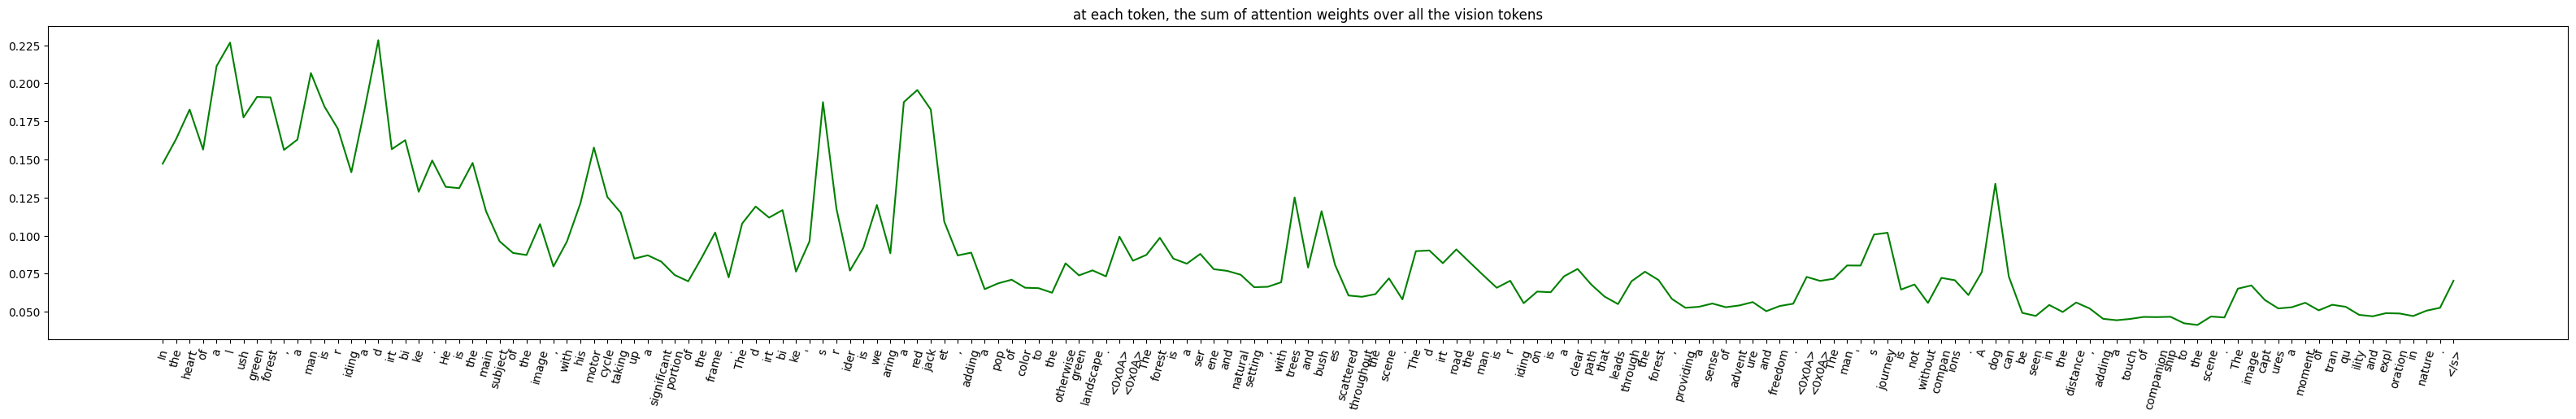

In [10]:
# look at the attention weights over the vision tokens
overall_attn_weights_over_vis_tokens = []
for i, (row, token) in enumerate(
    zip(
        llm_attn_matrix[input_token_len:], 
        output_sequences.tolist()
    )
):
    # print(
    #     i + input_token_len, 
    #     f"{tokenizer.decode(token, add_special_tokens=False).strip():<15}", 
    #     f"{row[vision_token_start:vision_token_end].sum().item():.4f}"
    # )

    overall_attn_weights_over_vis_tokens.append(
        row[vision_token_start:vision_token_end].sum().item()
    )

# plot the trend of attention weights over the vision tokens
fig, ax = plt.subplots(figsize=(40, 5))
ax.plot(overall_attn_weights_over_vis_tokens,color='green')
ax.set_xticks(range(len(overall_attn_weights_over_vis_tokens)))
ax.set_xticklabels(
    [tokenizer.decode(token, add_special_tokens=False).strip() for token in output_sequences.tolist()],
    rotation=75
)
ax.set_title("at each token, the sum of attention weights over all the vision tokens");

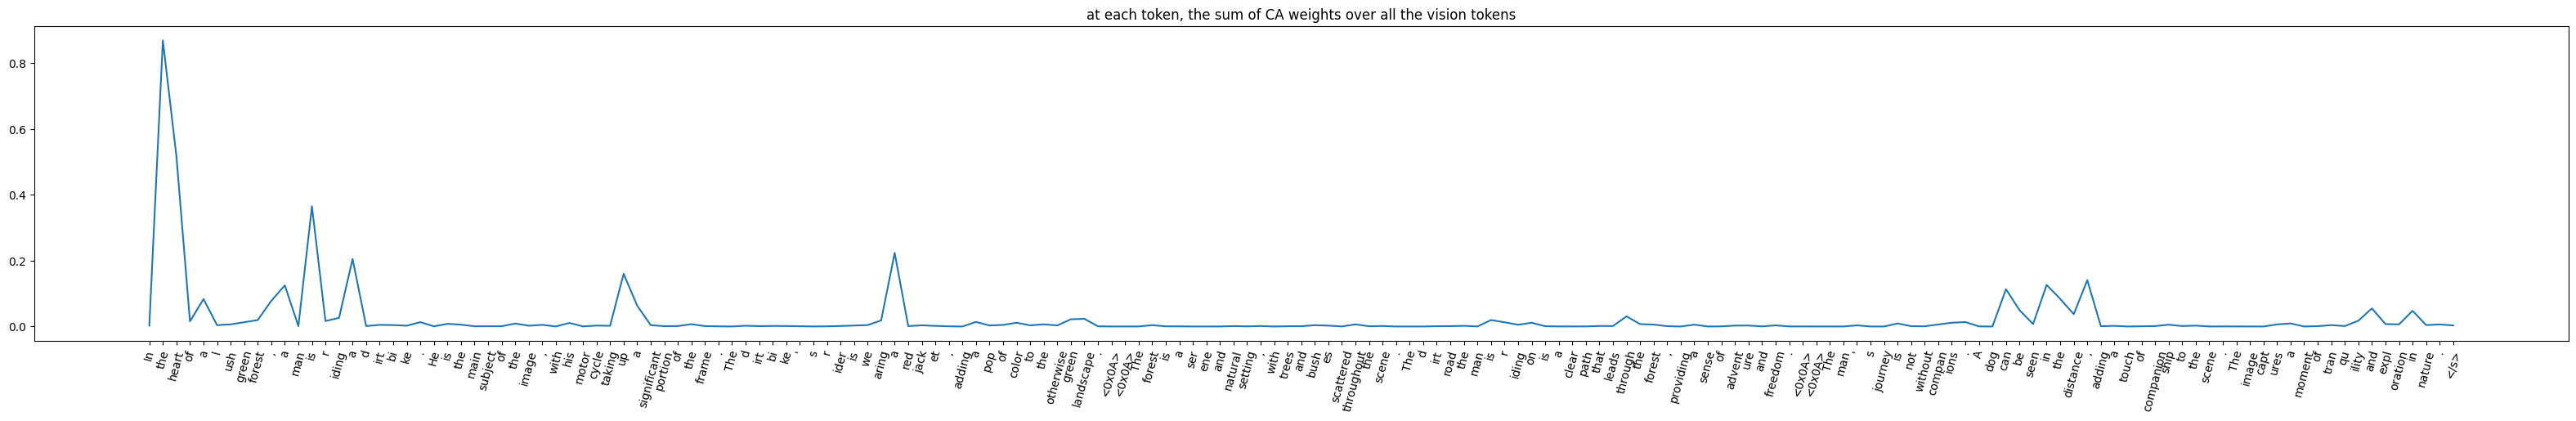

In [11]:
# look at the attention weights over the vision tokens
overall_attn_weights_over_vis_tokens = []
for i, (row, token) in enumerate(
    zip(
        ca_attns, 
        output_sequences.tolist()
    )
):
    # print(
    #     i + input_token_len, 
    #     f"{tokenizer.decode(token, add_special_tokens=False).strip():<15}", 
    #     f"{row[vision_token_start:vision_token_end].sum().item():.4f}"
    # )

    overall_attn_weights_over_vis_tokens.append(
        row[0][0][0].item()
    )

# plot the trend of attention weights over the vision tokens
fig, ax = plt.subplots(figsize=(40, 5))
ax.plot(overall_attn_weights_over_vis_tokens)
ax.set_xticks(range(len(overall_attn_weights_over_vis_tokens)))
ax.set_xticklabels(
    [tokenizer.decode(token, add_special_tokens=False).strip() for token in output_sequences.tolist()],
    rotation=75
)
ax.set_title("at each token, the sum of CA weights over all the vision tokens");

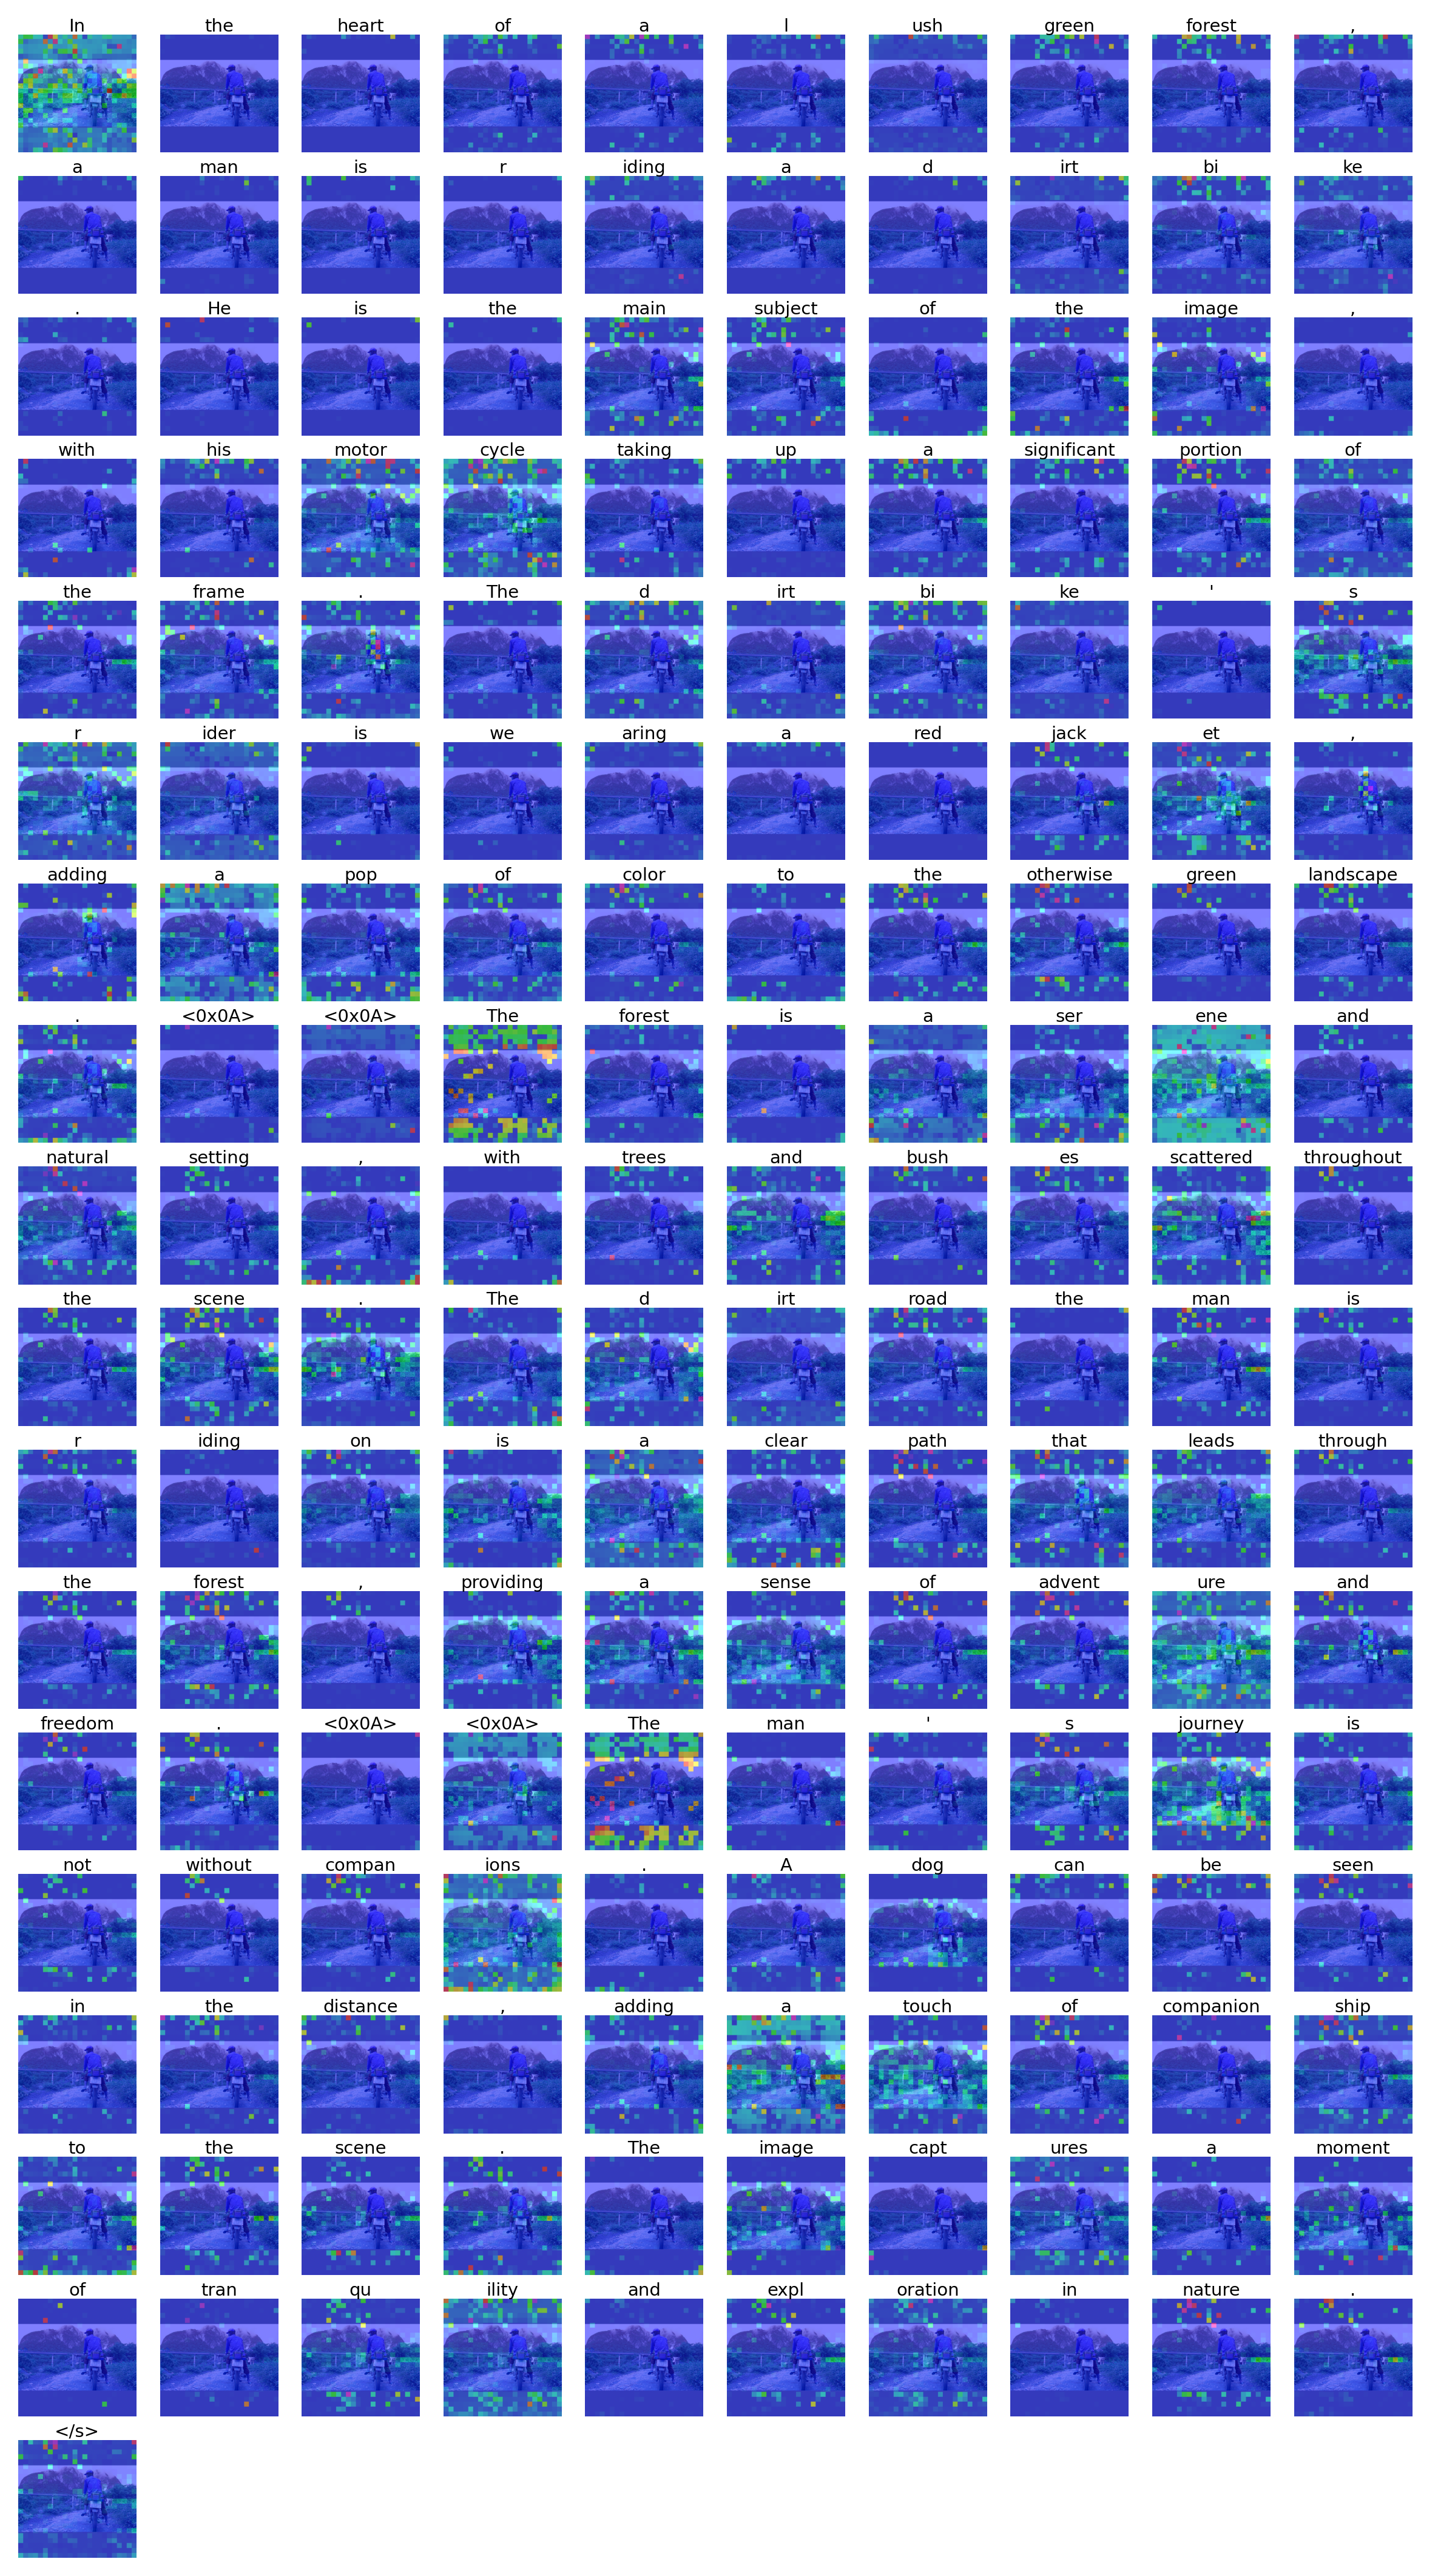

In [13]:
# grid_size = model.get_vision_tower().num_patches_per_side
grid_size = 24

num_image_per_row = 10
image_ratio = image_size[0] / image_size[1]
num_rows = output_token_len // num_image_per_row + (1 if output_token_len % num_image_per_row != 0 else 0)

fig, axes = plt.subplots(
    num_rows, num_image_per_row, 
    figsize=(10, (10 / num_image_per_row) * image_ratio * num_rows), 
    dpi=300
)
plt.subplots_adjust(wspace=0.05, hspace=0.2)

vis_overlayed_with_attn = True

output_token_inds = list(range(output_token_start, output_token_end))
for i, ax in enumerate(axes.flatten()):
    if i >= output_token_len:
        ax.axis("off")
        continue

    ca_attn = ca_attns[i][0][0]
    ca_attn = ca_attn.reshape(grid_size, grid_size)
    ca_attn = ca_attn / ca_attn.max()
    ca_attn = ca_attn.to(torch.float32)

    ca_attn = F.interpolate(
        ca_attn.unsqueeze(0).unsqueeze(0),
        size = image.size,
        mode = 'nearest',
        # mode='bicubic', align_corners=False,
    ).squeeze()

    np_img = np.array(image)[:, :, ::-1]
    img_with_attn, heatmap = show_mask_on_image(np_img, ca_attn.cpu().numpy())
    ax.imshow(heatmap if not vis_overlayed_with_attn else img_with_attn)
    ax.set_title(
        tokenizer.decode(output_sequences[i], add_special_tokens=False).strip(),
        fontsize=7,
        pad=1
    )
    ax.axis("off");


In [20]:
dir(model.get_vision_tower())

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_is_hf_initialized',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_no

In [14]:
# connect with the vision encoder attention
# to visualize the attention over the image

# vis_attn_matrix will be of torch.Size([N, N])
# where N is the number of vision tokens/patches
# `all_prev_layers=True` will average attention from all layers until the selected layer
# otherwise only the selected layer's attention will be used
vis_attn_matrix = aggregate_vit_attention(
    model.get_vision_tower().image_attentions,
    select_layer=model.get_vision_tower().select_layer,
    all_prev_layers=True
)
grid_size = model.get_vision_tower().num_patches_per_side

num_image_per_row = 10
image_ratio = image_size[0] / image_size[1]
num_rows = output_token_len // num_image_per_row + (1 if output_token_len % num_image_per_row != 0 else 0)

fig, axes = plt.subplots(
    num_rows, num_image_per_row, 
    figsize=(10, (10 / num_image_per_row) * image_ratio * num_rows), 
    dpi=300
)
plt.subplots_adjust(wspace=0.05, hspace=0.2)

# whether visualize the attention heatmap or 
# the image with the attention heatmap overlayed
vis_overlayed_with_attn = True

output_token_inds = list(range(output_token_start, output_token_end))
for i, ax in enumerate(axes.flatten()):
    if i >= output_token_len:
        ax.axis("off")
        continue

    target_token_ind = output_token_inds[i]
    attn_weights_over_vis_tokens = llm_attn_matrix[target_token_ind][vision_token_start:vision_token_end]
    attn_weights_over_vis_tokens = attn_weights_over_vis_tokens / attn_weights_over_vis_tokens.sum()

    attn_over_image = []
    for weight, vis_attn in zip(attn_weights_over_vis_tokens, vis_attn_matrix):
        vis_attn = vis_attn.reshape(grid_size, grid_size)
        # vis_attn = vis_attn / vis_attn.max()
        attn_over_image.append(vis_attn * weight)
    attn_over_image = torch.stack(attn_over_image).sum(dim=0)
    attn_over_image = (attn_over_image / attn_over_image.max()) * 3

    attn_over_image = attn_over_image.to(torch.float32)

    attn_over_image = F.interpolate(
        attn_over_image.unsqueeze(0).unsqueeze(0), 
        size=image.size, 
        mode='nearest', 
        # mode='bicubic', align_corners=False
    ).squeeze()

    np_img = np.array(image)[:, :, ::-1]
    img_with_attn, heatmap = show_mask_on_image(np_img, attn_over_image.numpy())
    ax.imshow(heatmap if not vis_overlayed_with_attn else img_with_attn)
    ax.set_title(
        tokenizer.decode(output_sequences[i], add_special_tokens=False).strip(),
        fontsize=7,
        pad=1
    )
    ax.axis("off");

AttributeError: 'CLIPVisionTower' object has no attribute 'image_attentions'

In [20]:
# connect with the vision encoder attention
# to visualize the attention over the image

# vis_attn_matrix will be of torch.Size([N, N])
# where N is the number of vision tokens/patches
# `all_prev_layers=True` will average attention from all layers until the selected layer
# otherwise only the selected layer's attention will be used
grid_size = model.get_vision_tower().num_patches_per_side

image_ratio = image_size[0] / image_size[1]

# whether visualize the attention heatmap or 
# the image with the attention heatmap overlayed
vis_overlayed_with_attn = True

output_token_inds = list(range(output_token_start, output_token_end))

overall_attn = torch.zeros((grid_size, grid_size)).to(torch.float32)

for i in range(output_token_len):

    target_token_ind = output_token_inds[i]
    attn_weights_over_vis_tokens = llm_attn_matrix[target_token_ind][vision_token_start:vision_token_end]
    attn_weights_over_vis_tokens = attn_weights_over_vis_tokens / attn_weights_over_vis_tokens.sum()

    attn_over_image = []
    for weight, vis_attn in zip(attn_weights_over_vis_tokens, vis_attn_matrix):
        vis_attn = vis_attn.reshape(grid_size, grid_size)
        # vis_attn = vis_attn / vis_attn.max()
        attn_over_image.append(vis_attn * weight)
    attn_over_image = torch.stack(attn_over_image).sum(dim=0)

    
    attn_over_image = attn_over_image / attn_over_image.max()

    attn_over_image = attn_over_image.to(torch.float32)

    overall_attn += attn_over_image

overall_attn = overall_attn / overall_attn.max()

overall_attn = F.interpolate(
    overall_attn.unsqueeze(0).unsqueeze(0),
    size = image.size,
    mode = 'nearest',
    # mode='bicubic', align_corners=|False,
).squeeze()

np_img = np.array(image)[:, :, :]
img_with_attn, heatmap = show_mask_on_image(np_img, overall_attn.numpy())
plt.imshow(heatmap if not vis_overlayed_with_attn else img_with_attn)
plt.axis("off");

AttributeError: 'CLIPVisionTower' object has no attribute 'num_patches_per_side'

In [21]:
attention_mask = (overall_attn > torch.quantile(overall_attn, 0.5)).float()
masked_img = np_img * attention_mask.cpu().numpy()[..., None]  # shape: (H, W, 3)

# 可视化 masked 图像
plt.imshow(masked_img.astype(np.uint8))
plt.axis("off")
# plt.title("Masked Image with High LLM Attention Regions")
plt.savefig('llm_mask.png',dpi=300)
plt.show()


NameError: name 'overall_attn' is not defined

In [22]:


ca_overall_attn = torch.zeros_like(ca_attns[0][0][0]).to(torch.float32)

for i in range(output_token_len):

    ca_attn = ca_attns[i][0][0]
    ca_attn = ca_attn.to(torch.float32)
    ca_attn = ca_attn / ca_attn.max()
    ca_overall_attn += ca_attn

ca_overall_attn = ca_overall_attn.reshape(grid_size, grid_size)
ca_overall_attn = ca_overall_attn / ca_overall_attn.max()

ca_overall_attn = F.interpolate(
    ca_overall_attn.unsqueeze(0).unsqueeze(0),
    size = image.size,
    mode = 'nearest',
    # mode='bicubic', align_corners=False,
).squeeze()

np_img = np.array(image)[:, :, :]
img_with_attn, heatmap = show_mask_on_image(np_img, ca_overall_attn.cpu().numpy())
plt.imshow(heatmap if not vis_overlayed_with_attn else img_with_attn)
plt.axis("off");

IndexError: list index out of range

In [23]:
attn_mask = (ca_overall_attn > torch.quantile(ca_overall_attn, 0.5)).float()

ca_masked_img = np_img * attn_mask.cpu().numpy()[..., None]  # shape: (H, W, 3)

# 可视化 masked 图像
plt.imshow(ca_masked_img.astype(np.uint8))
plt.axis("off")
# plt.title("Masked Image with High Cross-Attention Regions")
plt.savefig('ca_mask.png', dpi=300)
plt.show()


NameError: name 'ca_overall_attn' is not defined

In [24]:
len(ca_attns)

0